# Joint analysis of spatial and single-cell RNA-seq data with prior domain knowledge

Spatial transcriptomics provides a unique view of how gene expression varies across the architecture of complex tissues such as tumors.
However, current technologies often capture only a limited number of genes, making it challenging to uncover transcriptome-wide programs and their spatial organization.

To address this, we apply MOFA-FLEX to jointly analyze matched breast cancer datasets generated from two adjacent FFPE tissue sections:
One profiled with 10x Chromium single-cell RNA-seq for broad transcriptomic coverage, and another with 10x Xenium spatial transcriptomics for targeted spatial profiling.
By leveraging the complementary strengths of both assays, MOFA-FLEX integrates non-spatial and spatial data to infer biologically meaningful, spatially resolved gene programs that characterize the tumor microenvironment.

These datasets are publicly available from [10x Genomics](https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast).

In [1]:
from pathlib import Path
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import scanpy as sc
from plotnine import *
from tqdm.auto import tqdm

import mofaflex as mfl

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Loading and preprocessing the data

We jointly analyze two complementary breast cancer datasets generated from adjacent FFPE tissue sections:

- Chromium scRNA-seq providing broad transcriptomic coverage across thousands of genes, and
- Xenium spatial transcriptomics capturing the spatial organization of a targeted gene panel at near single-cell resolution.

We download all relevant files, remove low-quality Xenium cells that could not be assigned to a cell type, retain the top 3,000 most variable genes from the Chromium dataset to define the shared feature space, and load both datasets into separate MOFA-FLEX groups,.

In [2]:
class TqdmDownload(tqdm):
    def __init__(self, *args, **kwargs):
        kwargs = dict(kwargs)
        kwargs.update(
            {
                "unit": "B",
                "unit_scale": True,
                "unit_divisor": 1024,
                "dynamic_ncols": True,
            }
        )
        super().__init__(*args, **kwargs)
        self._have_total = False

    def update_to(self, nblocks=1, blocksize=1, total=-1):
        if not self._have_total:
            self.reset(total=total)
            self._have_total = True
        self.update(nblocks * blocksize - self.n)


def download_file(url, outfile):
    outfile = Path(outfile)
    outfile.parent.mkdir(exist_ok=True)

    with TqdmDownload(desc=f"downloading {outfile.name}") as t:
        urllib.request.urlretrieve(url, outfile, t.update_to)

# 10x blocks downloads of the Xenium dataset with the default user agent
opener = urllib.request.build_opener()
opener.addheaders.clear()
urllib.request.install_opener(opener)

celltypes = Path("data/celltypes.xlsx")
if not celltypes.is_file():
    download_file(
        "https://cdn.10xgenomics.com/raw/upload/v1695234604/Xenium%20Preview%20Data/Cell_Barcode_Type_Matrices.xlsx",
        "data/celltypes.xlsx",
    )

xeniumzip = Path("data/xenium/xenium.zip")
xenium_cells = Path(xeniumzip.parent) / "cells.csv.gz"
xenium_data = Path(xeniumzip.parent) / "cell_feature_matrix.h5"

if not xenium_cells.is_file() or not xenium_data.is_file():
    download_file(
        "https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_outs.zip",
        xeniumzip,
    )
    with zipfile.ZipFile(xeniumzip) as f:
        for fname in (xenium_cells.name, xenium_data.name):
            info = f.getinfo(f"outs/{fname}")
            info.filename = fname
            f.extract(info, xeniumzip.parent)
    xeniumzip.unlink()

chromium_data = Path("data/chromium/filtered_feature_bc_matrix.h5")
if not chromium_data.is_file():
    download_file(
        "https://cf.10xgenomics.com/samples/cell-exp/7.0.1/Chromium_FFPE_Human_Breast_Cancer_Chromium_FFPE_Human_Breast_Cancer/Chromium_FFPE_Human_Breast_Cancer_Chromium_FFPE_Human_Breast_Cancer_count_sample_filtered_feature_bc_matrix.h5",
        chromium_data,
    )


In [3]:
xenium = sc.read_10x_h5(xenium_data)
xenium_celltypes = (
    pd.read_excel(celltypes, sheet_name="Xenium R1 Fig1-5 (supervised)")
    .assign(Barcode=lambda x: x["Barcode"].astype(str))
    .rename(columns={"Cluster": "celltype"})
    .set_index("Barcode")
)
xenium_celltypes.index.name = None

xenium_metadata = pd.read_csv(xenium_cells).assign(cell_id=lambda x: x["cell_id"].astype(str)).set_index("cell_id")
xenium.obs = xenium_celltypes.join(xenium_metadata)
xenium.var = (xenium.var
              .drop(columns=["feature_types", "genome"]))
xenium.obsm["spatial"] = xenium.obs[["x_centroid", "y_centroid"]].to_numpy()

xenium = xenium[xenium.obs["celltype"] != "Unlabeled", :]

xenium.layers["counts"] = xenium.X.copy()
sc.pp.normalize_total(xenium)
sc.pp.log1p(xenium)

/tmp/ipykernel_2319342/2268612022.py:18: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.


In [4]:
chromium = sc.read_10x_h5(chromium_data)
chromium_celltypes = pd.read_excel(celltypes, sheet_name="scFFPE-Seq").set_index(
    "Barcode"
)
chromium.obs["celltype"] = chromium_celltypes["Annotation"]
chromium.var = chromium.var.drop(columns=["feature_types", "genome"])

chromium.layers["counts"] = chromium.X.copy()
sc.pp.normalize_total(chromium)
sc.pp.log1p(chromium)

/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [5]:
feature_vars = chromium.X.multiply(chromium.X).mean(axis=0).A.squeeze() - chromium.X.mean(axis=0).A.squeeze()**2
chromium = chromium[:, np.argsort(feature_vars)[-1:-3001:-1]]

## Loading and filtering gene set annotations (gene programs)

To guide the interpretation of latent factors, we incorporate prior biological knowledge from the MSigDB Hallmark collection.
Each gene set is converted to uppercase for compatibility with the dataset identifiers and filtered to retain only those with sufficient coverage within the Chromium scRNA-seq dataset (present in at least 20% of features and containing 25–300 genes).
These curated gene programs serve as interpretable annotations that link inferred latent factors to established biological pathways.

In [6]:
def to_upper(feature_set_collection):
    return mfl.FeatureSets(
        [
            mfl.FeatureSet([f.upper() for f in fs], fs.name)
            for fs in feature_set_collection
        ],
        name=feature_set_collection.name,
    )


gene_set_collection = to_upper(
    mfl.tl.msigdb_get_features(category="h.all", dbver="7.5.1")
).filter(
    chromium.var_names,
    min_fraction=0.2,
    min_count=25,
    max_count=300,
)

## Prettifying gene program names for better plotting

For clarity in downstream plots, we standardise and shorten gene program names.
This helper function removes technical prefixes (e.g. `HALLMARK_`, `REACTOME_`), replaces underscores with spaces, abbreviates overly long names, and tags each entry with its database source (`[H]` for Hallmark, `[R]` for Reactome).
Since we only use one database in this notebook, the tagging is omitted.
These formatted labels improve readability in UMAPs, heatmaps, and variance explained plots.

In [7]:
import re

def _prettify_name(
    name: str,
    mapper: dict[str, str] = None,
    abbreviation_length: int = 40,
    end_with_database: bool = True,
) -> str:
    if not isinstance(name, str):
        raise TypeError("`factor` must be a string.")
    if not isinstance(abbreviation_length, int) or abbreviation_length <= 0:
        raise ValueError("`abbreviation_length` must be a positive integer.")

    # Replace underscores with spaces
    name = name.replace("_", " ")

    # Replace using dictionary
    if mapper is not None:
        for key, value in mapper.items():
            name = name.replace(key, value)

    # Abbreviate if needed
    if len(name) > abbreviation_length:
        name = name[:abbreviation_length] + "…"

    # Move [X] from beginning to end, e.g. "[DB] Name" → "Name [DB]"
    if end_with_database:
        match = re.match(r"^(\[.*\]) (.*)", name)
        if match:
            name = f"{match.group(2)} {match.group(1)}"

    # Title case
    return name.title()


for gs in gene_set_collection:
    gs.name = _prettify_name(gs.name, mapper={"HALLMARK ": ""})

We convert the gene sets to a binary mask, which is stored in the AnnData object to be used by MOFA-FLEX.

In [8]:
chromium.varm["gene_set_mask"] = gene_set_collection.to_mask(
    chromium.var_names.tolist()
).T

/tmp/ipykernel_2319342/87263150.py:1: ImplicitModificationWarning: Setting element `.varm['gene_set_mask']` of view, initializing view as actual.


## Model configuration and training

Now everything is prepared and we can train a spatially informed MOFA-FLEX model to jointly learn latent factors across the matched Xenium spatial and Chromium scRNA-seq datasets.
The model integrates both groups under a shared latent representation, with Gaussian process priors applied to the spatial (Xenium) group to capture smooth spatial variation.
The Gaussian process uses an RBF kernel for spatial smoothing.
Hallmark gene programs are provided as annotations to constrain the factor loadings toward biologically meaningful pathways.
A Horseshoe prior encourages sparsity in the weights, while nonnegative constraints on factors and weights ensure interpretable, additive signal contributions.
The Horseshoe prior is also the only prior capable of handling prior domain knowledge.
Training is performed with 10,000-cell batches for up to 200 epochs.
A GPU is automatically used if present.

In [9]:
data_opts = mfl.DataOptions(
    scale_per_group=True,
    annotations_varm_key={"rna": "gene_set_mask"},
    covariates_obsm_key={"xenium": "spatial"},
    plot_data_overview=False,
)

model_opts = mfl.ModelOptions(
    n_factors=3,
    weight_prior="Horseshoe",
    factor_prior={"xenium": "GP", "chromium": "Normal"},
    likelihoods="Normal",
    nonnegative_weights=True,
    nonnegative_factors=True,
    annotation_confidence=0.999,
    init_factors=0.0,
)

training_opts = mfl.TrainingOptions(
    batch_size=10000,
    max_epochs=200,
    lr=0.003,
    seed=42,
)

smooth_opts = mfl.SmoothOptions(
    n_inducing=100,
    kernel="RBF",
)

model = mfl.MOFAFLEX(
    {"chromium": {"rna": chromium}, "xenium": {"rna": xenium}},
    data_opts,
    model_opts,
    training_opts,
    smooth_opts,
)

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/data/ilia/envs/famo/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
/data/ilia/envs/famo/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
INFO	Initializing factors using `0.0` method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 3
INFO	Saving results to mofaflex_20260622_102058.h5...
/data/ilia/famo/famo/src/mofaflex/_core/io.py:78: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.


## Downstream analysis: Variance explained across modalities

After training, we assess how much variance each latent factor explains in the RNA and protein modalities.
The variance explained (R²) plot quantifies the contribution of each factor to each view, allowing us to distinguish:
- shared factors that capture coordinated RNA–protein variation, likely reflecting underlying biological programs (e.g. cell-type or pathway-level structure),
- modality-specific factors that may correspond to technical effects or unique variation within a single omic layer.

By visualizing the fraction of variance explained, we can identify the dominant factors and ensure that both data modalities are well represented by the learned latent structure.

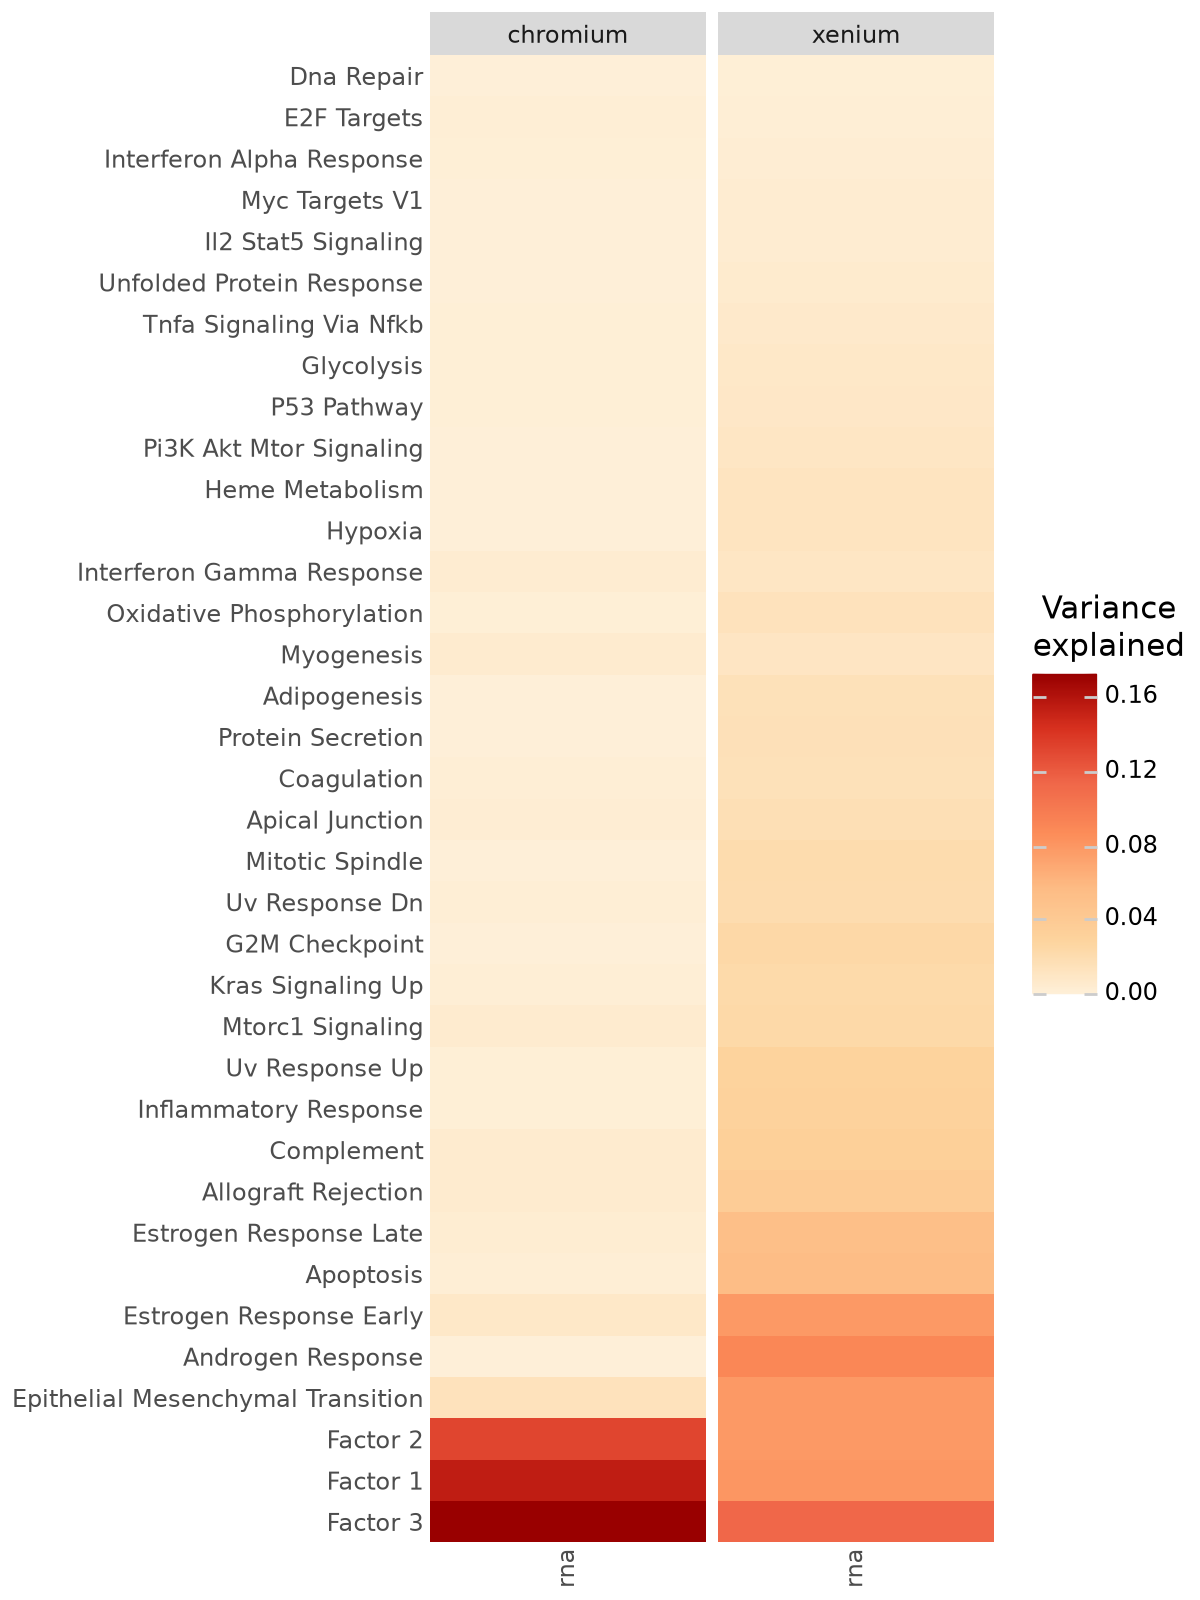

In [10]:
mfl.pl.variance_explained(model, figsize=(6, 8))

## Visualizing latent structure in a UMAP

To inspect the global organisation of the learned latent space, we project the factor scores (including both informed and uninformed factors) into two dimensions using UMAP.
This provides an intuitive overview of how samples cluster based on their shared molecular profiles.

In [11]:
factor_adata = model.get_factors("anndata")["xenium"]
# prettify cell type names
celltype_map = {
    "DCIS_2": "DCIS 2",
    "Macrophages_1": "Macrophages",
    "Invasive_Tumor": "Invasive Tumor",
    "Stromal": "Stromal",
    "CD4+_T_Cells": "T Cells",
    "CD8+_T_Cells": "T Cells",
    "Prolif_Invasive_Tumor": "Invasive Tumor",
    "Endothelial": "Endothelial",
    "Macrophages_2": "Macrophages",
    "T_Cell_&_Tumor_Hybrid": "T Cells & Tumor",
    "Myoepi_ACTA2+": "Myoepithelial",
    "B_Cells": "B Cells",
    "LAMP3+_DCs": "Dendritic Cells",
    "DCIS_1": "DCIS 1",
    "Perivascular-Like": "Perivascular Like",
    "Stromal_&_T_Cell_Hybrid": "Stromal & T Cells",
    "Myoepi_KRT15+": "Myoepithelial",
    "IRF7+_DCs": "Dendritic Cells",
    "Mast_Cells": "Mast Cells",
}

factor_adata.obs["Celltype"] = (
    factor_adata.obs["celltype"].map(celltype_map).fillna(factor_adata.obs["celltype"])
).astype("category")

In [12]:
sc.pp.neighbors(factor_adata, n_neighbors=15, use_rep="X")
sc.tl.umap(factor_adata, min_dist=0.4)

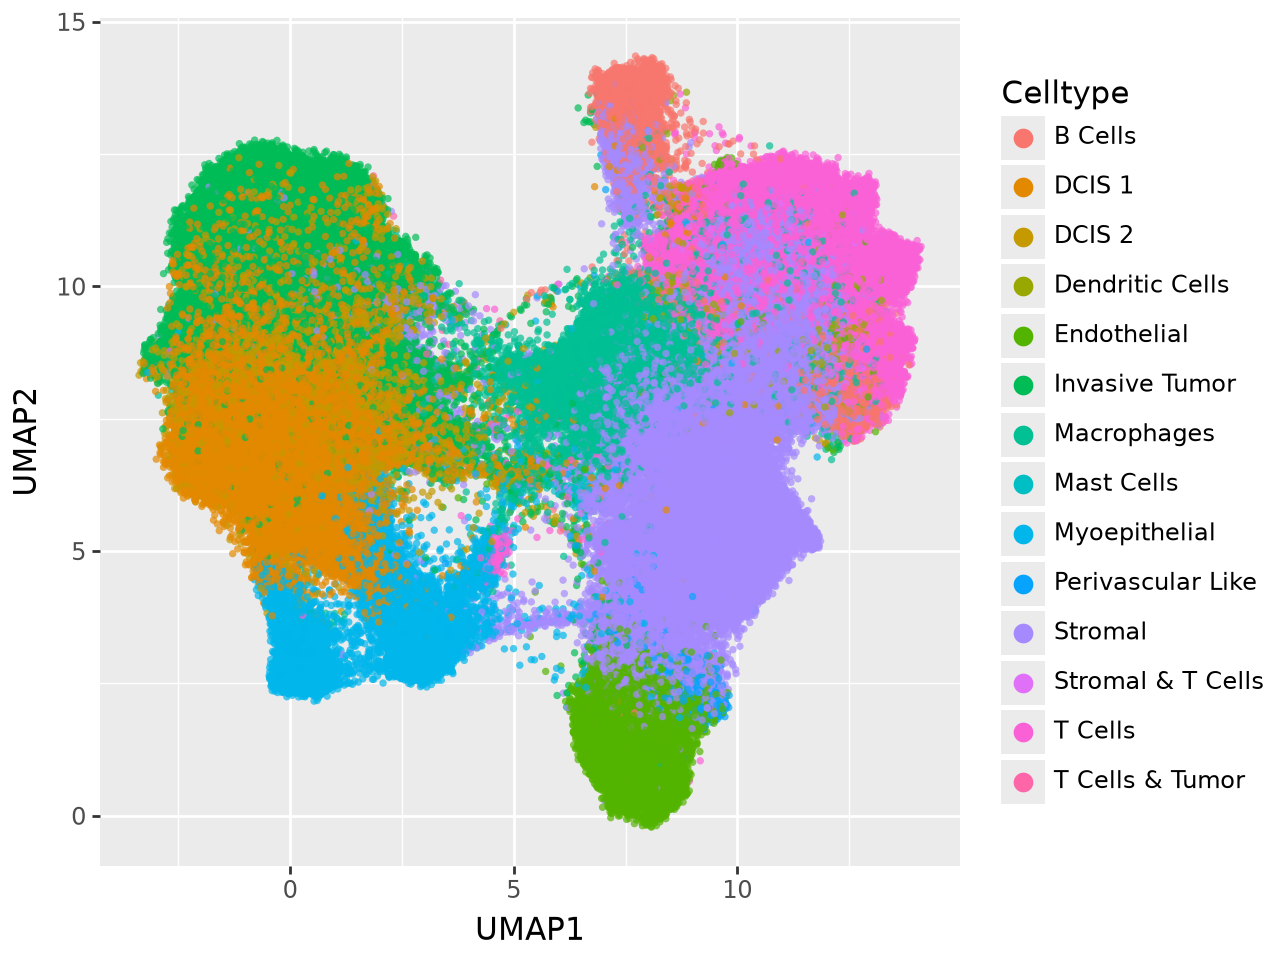

In [13]:
umap_df = pd.DataFrame(
    factor_adata.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=factor_adata.obs_names,
)
umap_df["Celltype"] = factor_adata.obs["Celltype"]

(
    ggplot(umap_df, aes(x="UMAP1", y="UMAP2", fill="Celltype"))
    + geom_point(stroke=0, alpha=0.7)
    + guides(fill=guide_legend(override_aes={"size": 4, "alpha": 1}))
)

## Ranking latent factors by cell type associations

To interpret the learned latent space, we can quantify which factors are most active in specific cell types.
This is analogous to marker gene ranking in Scanpy but applied to latent factors instead of genes.

The function below provides a minimal interface for this purpose. It:
- extracts the factor scores from the trained MOFA-FLEX model,
- uses `scanpy.tl.rank_genes_groups` to rank factors by their group-specific activity, and
- visualises the results as a dotplot (or heatmap, matrixplot, violin, etc.) for rapid interpretation.

This view highlights which factors capture distinct cell populations or experimental perturbations, providing an intuitive summary of how biological variation is structured in the latent space.

In [14]:
def rank(factor_adata, groupby, group_idx, n_factors=3, pl_type="dotplot", **kwargs):
    """
    Rank latent factors by association with sample groups and visualise as a Scanpy plot.
    Useful for factor activity summaries (e.g. dotplots).

    Parameters
    ----------
    factor_adata : AnnData
        Latent space.
    groupby : str
        Column in obs to group by (e.g. cell type or condition).
    group_idx : str
        Group key in model.get_factors("anndata") (e.g. "group_1").
    n_factors : int
        Number of top factors to plot per group.
    pl_type : str
        Type of Scanpy ranking plot: one of
        ["dotplot", "heatmap", "matrixplot", "violin", "stacked_violin"].
    **kwargs
        Additional arguments passed to Scanpy plotting function.
    """

    # Compute ranking of factors across groups
    sc.tl.rank_genes_groups(factor_adata, groupby)

    # Select plotting function
    pl_type = (pl_type or "dotplot").lower()
    type_to_fn = {
        "dotplot": sc.pl.rank_genes_groups_dotplot,
        "heatmap": sc.pl.rank_genes_groups_heatmap,
        "matrixplot": sc.pl.rank_genes_groups_matrixplot,
        "violin": sc.pl.rank_genes_groups_violin,
        "stacked_violin": sc.pl.rank_genes_groups_stacked_violin,
    }
    if pl_type not in type_to_fn:
        raise ValueError(f"Invalid pl_type '{pl_type}'. Choose from {list(type_to_fn.keys())}.")

    # Run plotting function (show by default)
    return type_to_fn[pl_type](factor_adata, n_genes=n_factors, **kwargs)

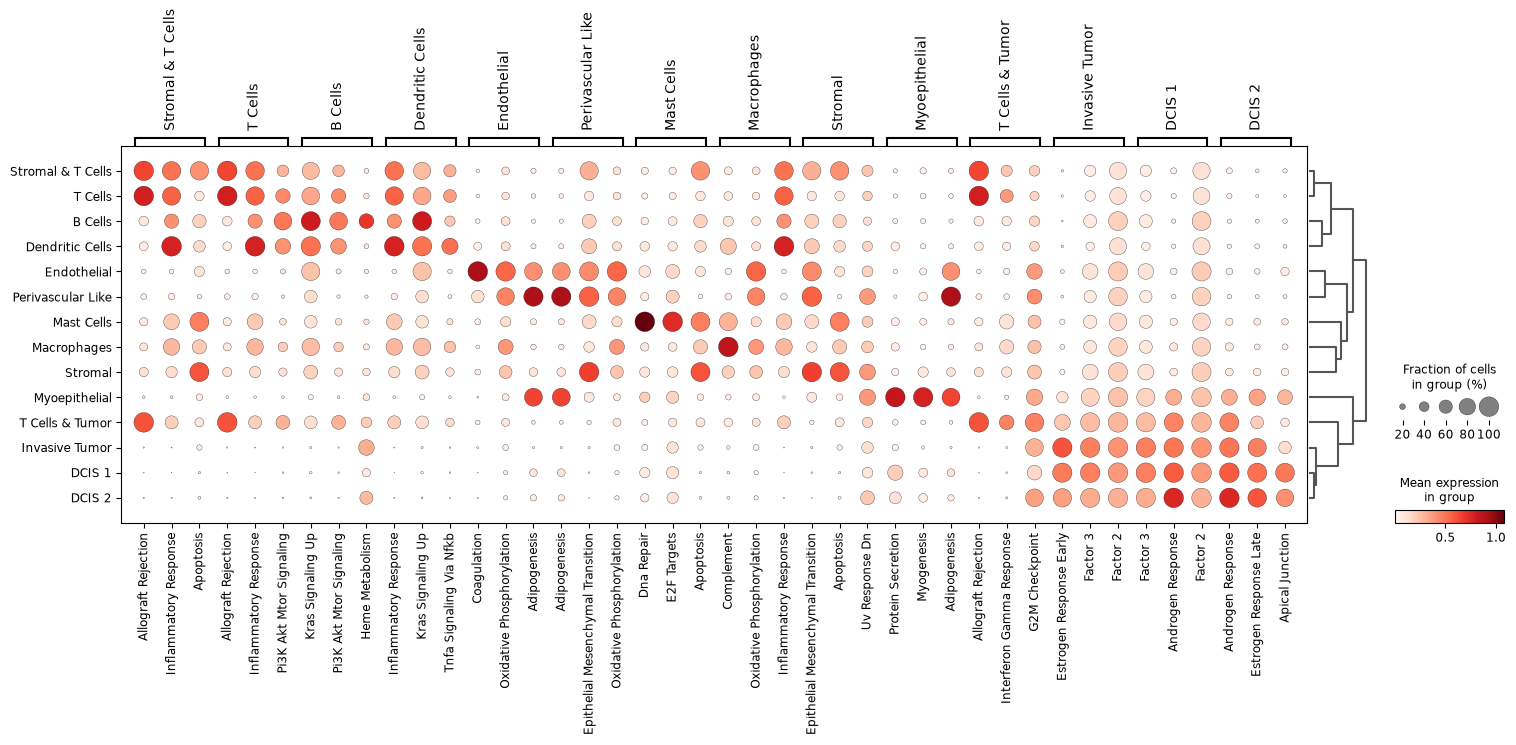

In [15]:
rank(
    factor_adata,
    "Celltype",
    group_idx="xenium",
    n_factors=3,
    pl_type="dotplot",
)

We can see that the "Estrogen Response Early" gene program is more active in invasive tumor cells compared to non-invasive DCIS cells.
On the other hand, the "Apical Junction" program is much more active in DCIS cells compared to invasive tumor cells.
We now plot the factor score distribution for these two programs in these cell types.

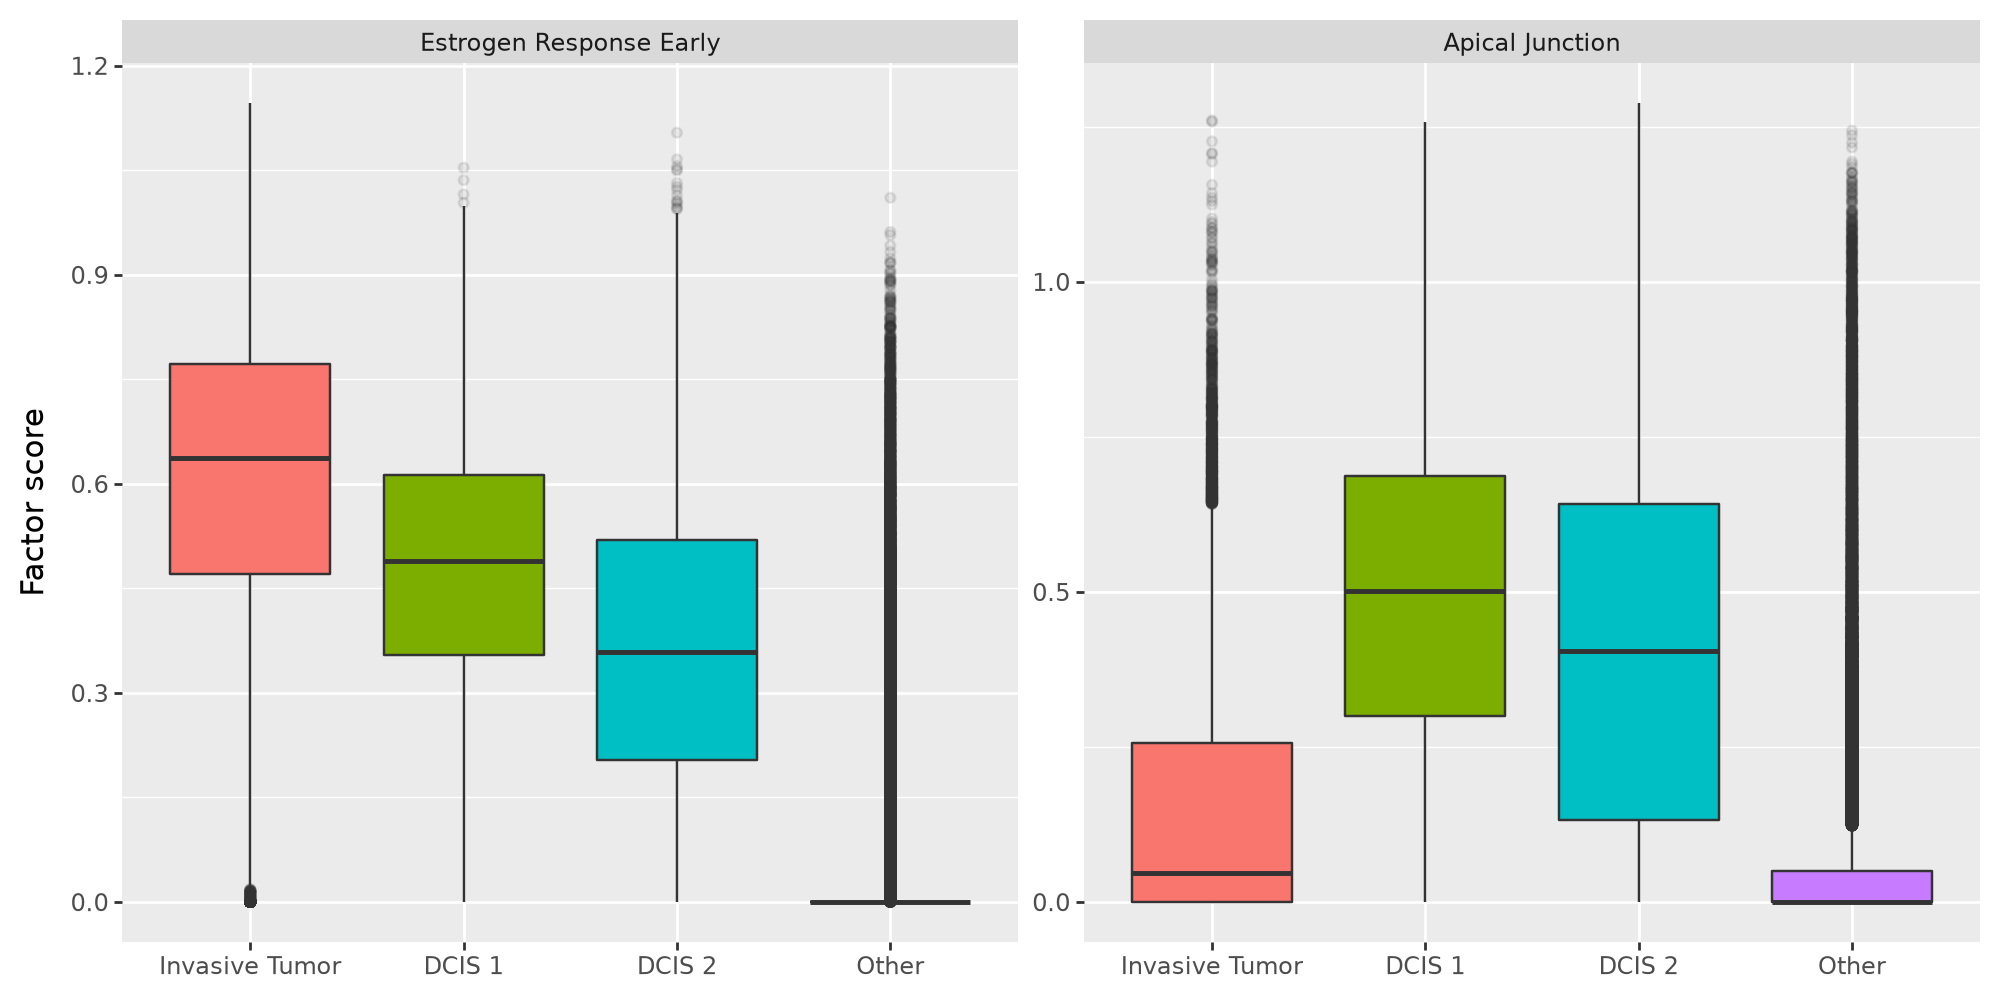

In [16]:
selected_factors = ["Estrogen Response Early", "Apical Junction"]

focus_groups = ["Invasive Tumor", "DCIS 1", "DCIS 2"]
cat_order = focus_groups + ["Other"]
df = (
    factor_adata.to_df()
    .loc[:, selected_factors]
    .assign(
        celltype=pd.Categorical(
            np.where(
                factor_adata.obs["Celltype"].isin(focus_groups),
                factor_adata.obs["Celltype"],
                "Other",
            ),
            categories=cat_order,
        )
    )
    .melt(id_vars="celltype", var_name="Factor", value_name="Factor score")
    .assign(Factor=lambda x: pd.Categorical(x["Factor"], categories=selected_factors))
)

(
    ggplot(df, aes(x="celltype", y="Factor score", fill="celltype"))
    + geom_boxplot(outlier_alpha=0.1)
    + facet_wrap("Factor", ncol=2, scales="free_y")
    + labs(x="")
    + theme(figure_size=(10, 5), legend_position="none")
)

We plot the 25 genes with the highest weghts for each program.
This gives as an impression of which genes contribute the most to these programs.
Furthermore, these plots indicate which genes that are not included in the annotation are still associated with the respective gene program in the dataset.

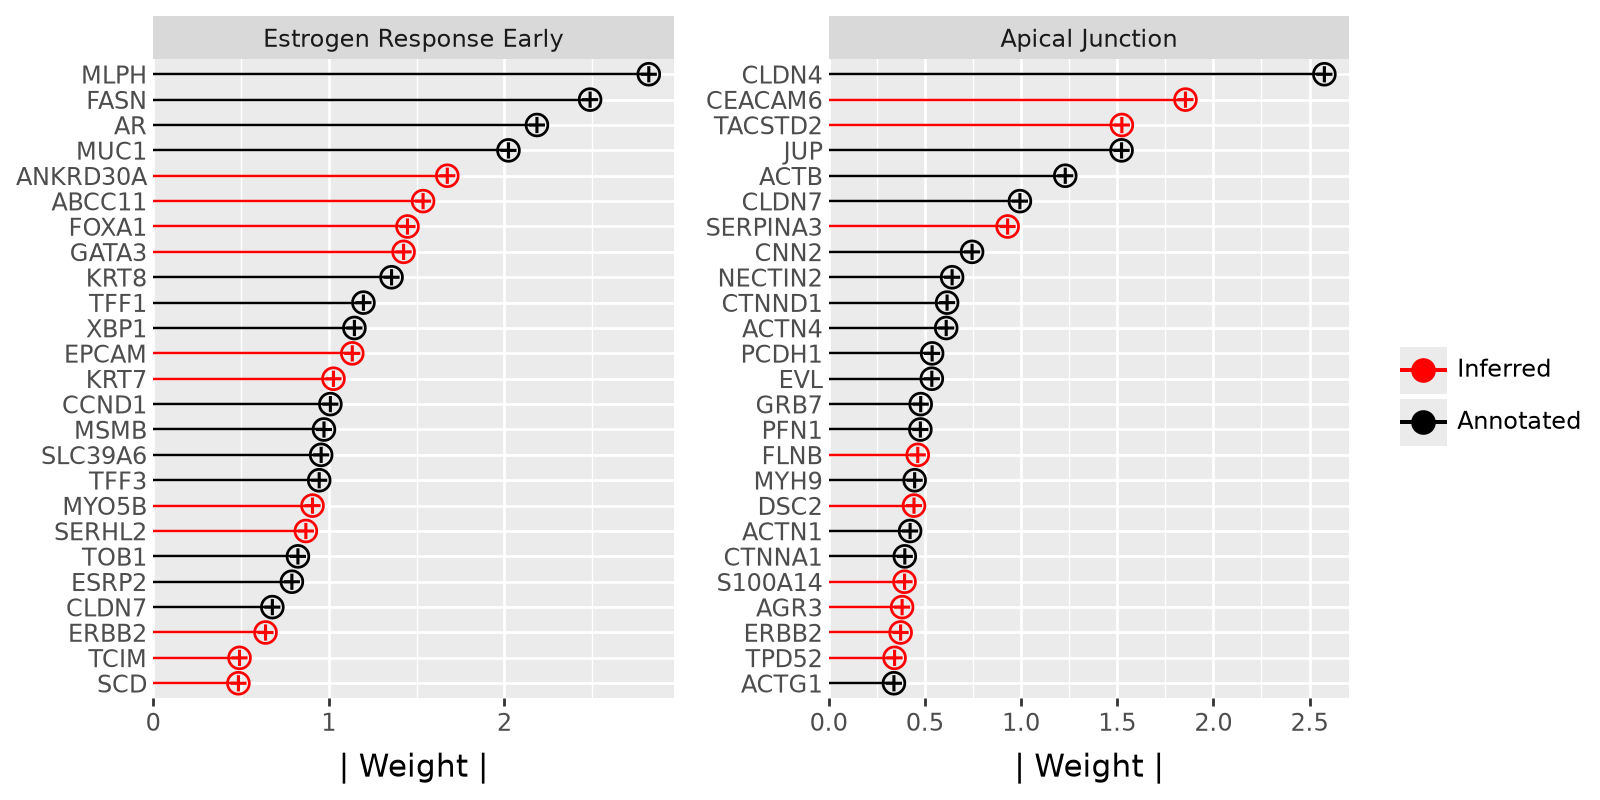

In [17]:
p1 = (
    mfl.pl.top_weights(model, n_features=25, views="rna", factors="Estrogen Response Early", figsize=(8, 4))
    + theme(legend_position="none")
)
p2 = mfl.pl.top_weights(model, n_features=25, views="rna", factors="Apical Junction", figsize=(8, 4))
p1 | p2

Finally, we can get some spatial context by plotting cell types and factor scores in space.

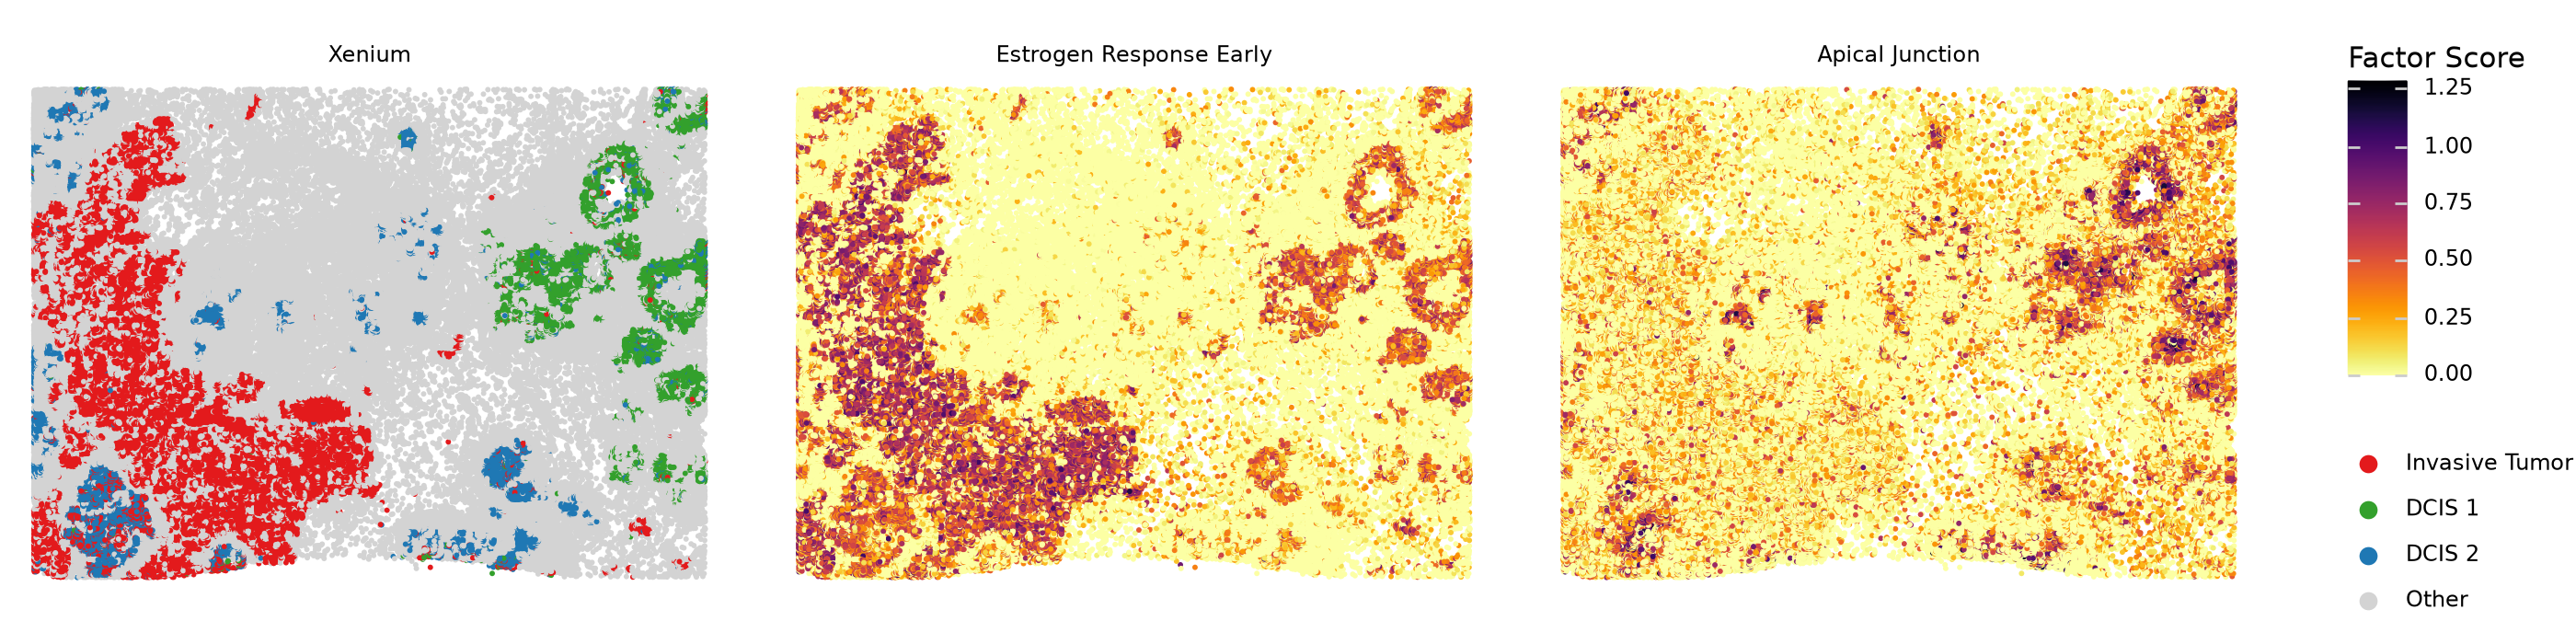

In [18]:
df = (
    model.get_factors(ordered=True)["xenium"]
    .join(
        pd.DataFrame(xenium.obsm["spatial"], index=xenium.obs_names, columns=["x", "y"])
    )
    .assign(
        celltype=np.where(
            factor_adata.obs["Celltype"].isin(("DCIS 1", "DCIS 2", "Invasive Tumor")),
            factor_adata.obs["Celltype"],
            "Other",
        )
    )
    .melt(
        id_vars=["x", "y", "celltype"],
        value_vars=["Estrogen Response Early", "Apical Junction"],
        var_name="view",
        value_name="value",
    )
    .assign(
        view=lambda x: pd.Categorical(
            x["view"],
            categories=["Xenium", "Estrogen Response Early", "Apical Junction"],
        )
    )
)

(
    ggplot(df, aes("x", "y"))
    + geom_point(
        data=df.iloc[: df.shape[0] // 2, :].assign(view=lambda x: pd.Categorical(["Xenium"] * x.shape[0], categories=x["view"].cat.categories)),
        mapping=aes(fill="celltype"),
        size=1.2,
        stroke=0,
    )
    + geom_point(mapping=aes(color="value"), size=1.2, stroke=0)
    + guides(fill=guide_legend(override_aes={"size": 4}, title=""))
    + scale_color_cmap(name="Factor Score", cmap_name="inferno_r")
    + scale_fill_manual(
        limits=cat_order, values=["#e31a1c", "#33a02c", "#1f78b4", "#d3d3d3"]
    )
    + facet_wrap("view", ncol=3, scales="fixed", labeller="label_value", drop=False)
    + coord_equal()
    + theme_void()
    + theme(
        figure_size=(14, 3.5),
        legend_position="right",
    )
)